# DLinear experiment - Walmart Store Sales Forecasting

Person B track (DL + Prophet). This is the first of the four notebooks in this
track (`docs/person_b_dl_prompt.md` / `docs/person_b_dl_prophet_guide.md`) -
DLinear is done first because it is the simplest darts global model and
proves the whole panel-build -> fit -> backtest -> MLflow -> wrapper harness
end to end, before N-BEATS / TFT-or-PatchTST / Prophet reuse it.

**Decisions this notebook needs to record for the README:**
- future vs past covariate split (verified against `features.csv` coverage, not assumed)
- confirmed weekly frequency
- target scaling strategy given zero/negative `Weekly_Sales`
- validation strategy (expanding-window, shared with Person A once `src/validation.py` exists)

**Assumptions flagged inline:** a few exact function signatures in
`src/preprocessing.py` / `src/evaluation.py` are inferred from `CLAUDE.md`'s
description rather than the literal source (not included in what was shared
with me). Anywhere this matters is marked `# ASSUMPTION:` - fix the call if the
real signature differs.


##  Init cell (Colab-compatible)

Byte-identical to the N-BEATS notebook's init cell (`model_experiment_nbeats.ipynb`),
which is itself derived from `notebooks/EDA.ipynb`'s first cell plus a `darts[torch]`
install - keeping both DL notebooks' bootstrap in sync.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

IS_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IS_COLAB:
    REPO_URL = "https://github.com/NikaMikeltadze/walmart-sales-forecasting.git"  # TODO: fill in
    REPO_DIR = "/content/walmart-sales-forecasting"

    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r",
         f"{REPO_DIR}/requirements.txt", "--quiet"],
        check=True,
    )
    subprocess.run([sys.executable, "-m", "pip", "install", "darts[torch]", "--quiet"], check=True)

    os.chdir(f"{REPO_DIR}/notebooks")

    from google.colab import drive
    drive.mount("/content/drive")

    drive_data_dir = Path("/content/drive/MyDrive/walmart-sales-forecasting/data/raw")
    repo_data_dir = Path(REPO_DIR) / "data" / "raw"
    if drive_data_dir.exists():
        subprocess.run(["cp", "-r", f"{drive_data_dir}/.", str(repo_data_dir)], check=True)
    else:
        raise FileNotFoundError(
            f"Expected Drive data folder not found at {drive_data_dir}. "
            "Create it (or add it as a My Drive shortcut) before running this notebook."
        )

sys.path.append(str(Path.cwd().parent))


Mounted at /content/drive


##  Imports

In [2]:
import pickle
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from sklearn.preprocessing import StandardScaler

from darts import TimeSeries
from darts.models import DLinearModel
from darts.dataprocessing.transformers import Scaler

from src.preprocessing import load_raw_data, WalmartPreprocessor
from src.features import add_temporal_features
from src.evaluation import weighted_mae  # ASSUMPTION: signature (y_true, y_pred, is_holiday) -> float

pd.set_option("display.max_columns", 50)
pd.set_option("future.no_silent_downcasting", True)


###  Manual credentials override (VS Code / non-Colab-UI runtimes)

`google.colab.userdata` (Colab Secrets) can only be read from the Colab
**browser UI**. When the Colab runtime is driven from VS Code or any other
non-UI frontend it times out (`Secrets can only be fetched when running from
the Colab UI`). This cell sets the DagsHub creds directly instead, and the
credentials cell below skips `userdata` whenever these env vars are already set.

`getpass` is used so the token is never written into this committed notebook -
run the cell and paste the values when prompted. Leave a prompt blank to fall
through to Colab Secrets / `.env` below (e.g. when you *are* on the Colab UI).

In [3]:
import os
from getpass import getpass

# Only prompt for values not already set, so re-running cells doesn't re-ask.
# Leave a prompt blank to fall through to Colab Secrets / .env in the next cell.
if not os.environ.get("MLFLOW_TRACKING_USERNAME"):
    _user = getpass("DagsHub username (blank -> use Colab Secrets / .env): ").strip()
    if _user:
        os.environ["MLFLOW_TRACKING_USERNAME"] = _user
if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    _token = getpass("DagsHub token (blank -> use Colab Secrets / .env): ").strip()
    if _token:
        os.environ["MLFLOW_TRACKING_PASSWORD"] = _token

##  Load DagsHub credentials

`MLFLOW_TRACKING_USERNAME`/`MLFLOW_TRACKING_PASSWORD` are never hardcoded in
this notebook (it gets committed to the shared repo, so a hardcoded token
would leak).

- On the Colab UI: read from Colab secrets - add `DAGSHUB_USERNAME` and
  `DAGSHUB_TOKEN` via the key icon in the left sidebar, and enable
  "Notebook access" for both. Same approach as the other notebooks.
- From VS Code / non-UI runtimes: use the manual-override cell above.
- Locally: falls back to a gitignored `.env` in the repo root.

In [4]:
if os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    # Already provided (e.g. by the manual-override cell above when driving the
    # Colab runtime from VS Code, where google.colab.userdata would time out).
    # Note: userdata.get(...) must NOT be evaluated in this case - it blocks for
    # ~minutes and raises when there is no Colab browser UI to answer it.
    creds_source = "pre-set environment variables"
elif IS_COLAB:
    from google.colab import userdata

    os.environ["MLFLOW_TRACKING_USERNAME"] = userdata.get("DAGSHUB_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = userdata.get("DAGSHUB_TOKEN")
    creds_source = "Colab secrets (DAGSHUB_USERNAME / DAGSHUB_TOKEN)"
else:
    from dotenv import load_dotenv

    env_path = Path.cwd().parent / ".env"
    load_dotenv(env_path)
    creds_source = str(env_path)

assert os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"), (
    f"MLFLOW_TRACKING_USERNAME/PASSWORD not set (tried: {creds_source}). "
    "On the Colab UI: add DAGSHUB_USERNAME and DAGSHUB_TOKEN as Colab secrets "
    "(key icon in the left sidebar) and enable notebook access for both. "
    "From VS Code / non-UI runtimes: run the manual-override cell above. "
    "Locally: create a .env in the repo root with MLFLOW_TRACKING_USERNAME=... "
    "and MLFLOW_TRACKING_PASSWORD=..."
)
print("MLflow credentials loaded from:", creds_source)

MLflow credentials loaded from: pre-set environment variables


##  MLflow tracking store

Shared DagsHub MLflow server - the single source of truth for cross-model
WMAE comparison and the Model Registry, so all 7 models (both tracks) log
here rather than to a per-notebook local store. Does not silently fall back
to a local store if auth fails - that would desync DLinear's runs from the
rest of the team's.

In [5]:
MLFLOW_TRACKING_URI = "https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    mlflow.set_experiment("DLinear_Training")
    mlflow.MlflowClient().search_experiments(max_results=1)  # force a network round trip now
except Exception as e:
    raise RuntimeError(
        "Could not authenticate to the DagsHub MLflow server at "
        f"{MLFLOW_TRACKING_URI}. Set MLFLOW_TRACKING_USERNAME and "
        "MLFLOW_TRACKING_PASSWORD (a DagsHub access token) as environment "
        "variables, then re-run this cell. Not falling back to local "
        "./mlruns or sqlite - that would desync from Person A's XGBoost/"
        "LightGBM runs and the rest of the team's runs."
    ) from e

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("DLinear_Training").name)

2026/07/11 23:39:08 INFO mlflow.tracking.fluent: Experiment with name 'DLinear_Training' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow
Active experiment: DLinear_Training


##  Load, merge, clean

Reuses `load_raw_data` / `WalmartPreprocessor` rather than reimplementing
loading logic (per `CLAUDE.md`). `WalmartPreprocessor.fit()` loads and caches
`features_` / `stores_` internally.


In [6]:
# 1. Load the raw data dictionary
raw_data = load_raw_data(data_dir="../data/raw")

# 2. Extract by key names to get the actual DataFrames
train_raw = raw_data["train"]
test_raw = raw_data["test"]

# 3. Fit and transform using the preprocessor
preprocessor = WalmartPreprocessor(data_dir="../data/raw")
preprocessor.fit(train_raw)

train_clean = preprocessor.transform(train_raw)
test_clean = preprocessor.transform(test_raw)

train_feat = add_temporal_features(train_clean)
test_feat = add_temporal_features(test_clean)

print(train_feat.shape, test_feat.shape)
train_feat.head()

(421570, 23) (115064, 22)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,week_of_year,month,year,days_to_super_bowl,days_to_labor_day,days_to_thanksgiving,days_to_christmas
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,2,2010,7,217,294,329
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,2,2010,0,210,287,322
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,2,2010,-7,203,280,315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,8,2,2010,-14,196,273,308
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,3,2010,-21,189,266,301


##  Covariate coverage decision 

Determined by actually checking `features.csv` against the test date range,
not assumed - a column only becomes a *future* covariate if it's non-null for
every week of the test horizon (2012-11-02 to 2013-07-26).


In [7]:
test_dates = pd.date_range("2012-11-02", "2013-07-26", freq="W-FRI")

macro_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment",
              "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

features_lookup = preprocessor.features_  # ASSUMPTION: cached raw features frame, has Store/Date/<macro_cols>

coverage = {}
for col in macro_cols:
    non_null_dates = set(features_lookup.loc[features_lookup[col].notna(), "Date"])
    coverage[col] = set(test_dates).issubset(non_null_dates)

coverage_df = pd.Series(coverage, name="covers_full_test_range")
print(coverage_df)

calendar_future_cols = ["IsHoliday", "week_of_year", "month", "year",
                         "days_to_super_bowl", "days_to_labor_day",
                         "days_to_thanksgiving", "days_to_christmas"]

FUTURE_COVARIATE_COLS = calendar_future_cols + [c for c in coverage_df.index if coverage_df[c]]
PAST_COVARIATE_COLS = [c for c in coverage_df.index if not coverage_df[c]]
all_covariate_cols = FUTURE_COVARIATE_COLS + PAST_COVARIATE_COLS

print("Future covariates:", FUTURE_COVARIATE_COLS)
print("Past covariates:", PAST_COVARIATE_COLS)


Temperature      True
Fuel_Price       True
CPI              True
Unemployment     True
MarkDown1        True
MarkDown2       False
MarkDown3        True
MarkDown4        True
MarkDown5        True
Name: covers_full_test_range, dtype: bool
Future covariates: ['IsHoliday', 'week_of_year', 'month', 'year', 'days_to_super_bowl', 'days_to_labor_day', 'days_to_thanksgiving', 'days_to_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Past covariates: ['MarkDown2']


##  Model definition and covariate support check

Check what the *installed* darts version's `DLinearModel` actually accepts
before assuming past/future/static support - this has changed across darts
releases. Unlike N-BEATS, DLinear in the installed darts version supports
past, future, **and** static covariates, so it can see known-future signals
like `IsHoliday` and the `days_to_*` holiday-distance features directly - a
real architectural advantage worth calling out in the README comparison.

In [8]:
import torch

FREQ = "W-FRI"
inferred_freq = pd.infer_freq(sorted(train_feat["Date"].unique()))
print("Inferred frequency from data:", inferred_freq)
assert inferred_freq in ("W-FRI", None), f"Unexpected frequency: {inferred_freq}"

INPUT_CHUNK_LENGTH = 52   # one year of history
OUTPUT_CHUNK_LENGTH = 39  # covers the full test horizon - test is ~39 weeks past train
MIN_REQUIRED_LENGTH = INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH  # darts needs this much history in every training series
CV_N_EPOCHS = 10     # ceiling per CV fold - kept small since this trains 3 separate models
FINAL_N_EPOCHS = 20  # ceiling for the single final fit on full history

# Same architecture everywhere (every CV fold and the final model) so what gets
# validated is actually what gets deployed.
DLINEAR_ARCH_KWARGS = dict(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    random_state=42,
)


def make_accelerator_kwargs(callbacks=None):
    """pl_trainer_kwargs shared by every fit call below, so GPU selection is consistent."""
    backend = "gpu" if torch.cuda.is_available() else "cpu"
    kwargs = {"accelerator": backend, "callbacks": callbacks or []}
    if backend == "gpu":
        kwargs["devices"] = 1
    return kwargs


# Throwaway, unfit instance just to introspect covariate support - cheap (no .fit() call).
_support_probe = DLinearModel(n_epochs=1, batch_size=32, **DLINEAR_ARCH_KWARGS)
SUPPORTS_PAST = _support_probe.supports_past_covariates
SUPPORTS_FUTURE = _support_probe.supports_future_covariates

print("Supports past covariates:", SUPPORTS_PAST)
print("Supports future covariates:", SUPPORTS_FUTURE)
print("Supports static covariates:", _support_probe.supports_static_covariates)

if SUPPORTS_FUTURE:
    DLINEAR_PAST_COLS = PAST_COVARIATE_COLS
    DLINEAR_FUTURE_COLS = FUTURE_COVARIATE_COLS
else:
    DLINEAR_PAST_COLS = all_covariate_cols
    DLINEAR_FUTURE_COLS = []

print("Columns fed as past_covariates:", DLINEAR_PAST_COLS)
print("Columns fed as future_covariates:", DLINEAR_FUTURE_COLS)

Inferred frequency from data: W-FRI
Supports past covariates: True
Supports future covariates: True
Supports static covariates: True
Columns fed as past_covariates: ['MarkDown2']
Columns fed as future_covariates: ['IsHoliday', 'week_of_year', 'month', 'year', 'days_to_super_bowl', 'days_to_labor_day', 'days_to_thanksgiving', 'days_to_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'MarkDown5']


##  Build the darts panel (gap-interpolated target, store-level covariates)

Built once, correctly, instead of iterated on in place (an earlier version
of this cell rebuilt `build_darts_series`/`store_cov_series` three separate
times as bugs were found - consolidated here). Target gaps get linearly
interpolated (interior missing weeks, not 0-sales weeks); covariates are
built once per Store, spanning train+test, immune to any single
department's short test presence.

In [9]:
def build_darts_series(df, value_col="Weekly_Sales", covariate_cols=None, freq=FREQ):
    """
    Convert a long-format (Store, Dept, Date, ...) frame into darts TimeSeries,
    one per (Store, Dept). Target gaps are linearly interpolated (genuine
    missing weeks, not 0-sales weeks). Covariate gaps are ffill/bfill'd.
    """
    covariate_cols = covariate_cols or []
    series_list, covariate_series_list, keys = [], [], []

    for (store, dept), g in df.groupby(["Store", "Dept"]):
        g = g.sort_values("Date")
        full_range = pd.date_range(g["Date"].min(), g["Date"].max(), freq=freq)
        g = g.set_index("Date").reindex(full_range)
        g.index.name = "Date"

        if value_col in g.columns:
            filled = g[value_col].interpolate(method="linear", limit_direction="both")
            series_list.append(TimeSeries.from_series(filled, freq=freq))

        if covariate_cols:
            cov = g[covariate_cols].ffill().bfill()
            covariate_series_list.append(TimeSeries.from_dataframe(cov, freq=freq))

        keys.append((store, dept))

    return series_list, (covariate_series_list or None), keys


def build_store_level_covariates(df, covariate_cols, global_start, global_end, freq=FREQ):
    """One covariate TimeSeries per Store (covariates don't vary by Dept),
    spanning the full global range so it's always long enough for any
    forecast horizon regardless of any single Dept's data gaps."""
    store_level = df.drop_duplicates(subset=["Store", "Date"])[["Store", "Date"] + covariate_cols]
    store_cov = {}
    for store, g in store_level.groupby("Store"):
        g = g.sort_values("Date").set_index("Date")
        full_range = pd.date_range(global_start, global_end, freq=freq)
        g = g.reindex(full_range)
        g.index.name = "Date"
        g[covariate_cols] = g[covariate_cols].ffill().bfill()
        store_cov[store] = TimeSeries.from_dataframe(g[covariate_cols], freq=freq)
    return store_cov


def split_past_future(cov_list, future_cols, past_cols):
    future_list = [ts[future_cols] for ts in cov_list] if future_cols else None
    past_list = [ts[past_cols] for ts in cov_list] if past_cols else None
    return past_list, future_list


target_series, _, series_keys = build_darts_series(train_feat, covariate_cols=[], freq=FREQ)
print(f"Built {len(target_series)} target series for {len(series_keys)} (Store, Dept) pairs.")

full_feat_df = pd.concat([train_feat, test_feat], ignore_index=True).drop_duplicates(
    subset=["Store", "Dept", "Date"]
)
numeric_cols = [c for c in all_covariate_cols if c not in ["Store", "Dept", "Date"]]
df_scaler = StandardScaler()
train_dates = train_feat["Date"].unique()
df_scaler.fit(full_feat_df.loc[full_feat_df["Date"].isin(train_dates), numeric_cols])
full_feat_scaled_df = full_feat_df.copy()
full_feat_scaled_df[numeric_cols] = df_scaler.transform(full_feat_df[numeric_cols])

GLOBAL_START = full_feat_scaled_df["Date"].min()
GLOBAL_END = full_feat_scaled_df["Date"].max()
print(f"Covariates span {GLOBAL_START} -> {GLOBAL_END}")

store_cov_series = build_store_level_covariates(
    full_feat_scaled_df, all_covariate_cols, GLOBAL_START, GLOBAL_END, freq=FREQ
)

Built 3331 target series for 3331 (Store, Dept) pairs.
Covariates span 2010-02-05 00:00:00 -> 2013-07-26 00:00:00


## Time-based CV: expanding-window splits

Uses the real shared `src/validation.py` splitter - same one Person A's
XGBoost/LightGBM notebooks (and the N-BEATS notebook) use
(`expanding_window_splits`), so WMAE numbers are directly comparable across
all 7 models. An earlier version of this notebook tried to import a
`time_based_split` name that was never actually defined in
`src/validation.py`, so it silently always fell back to a single ad-hoc
global split instead of real multi-fold CV - fixed here to import the real
function directly.

Same 3 folds / 13-week validation windows as the XGBoost and N-BEATS
notebooks.

In [10]:
from src.validation import expanding_window_splits, split_series, describe_split

N_SPLITS = 3
VAL_WEEKS = 13
MIN_TRAIN_WEEKS = 52

splits = expanding_window_splits(
    train_feat["Date"], n_splits=N_SPLITS, val_weeks=VAL_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS
)
assert len(splits) == N_SPLITS, "history too short for the requested number of folds"

for i, split in enumerate(splits):
    print(f"fold {i}:", describe_split(split))

fold 0: {'train_start': 'start_of_history', 'train_end': '2012-01-27 00:00:00', 'val_start': '2012-02-03 00:00:00', 'val_end': '2012-04-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}
fold 1: {'train_start': 'start_of_history', 'train_end': '2012-04-27 00:00:00', 'val_start': '2012-05-04 00:00:00', 'val_end': '2012-07-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 0}
fold 2: {'train_start': 'start_of_history', 'train_end': '2012-07-27 00:00:00', 'val_start': '2012-08-03 00:00:00', 'val_end': '2012-10-26 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}


##  Log covariate/architecture decisions (`DLinear_Feature_Selection`)

Lightweight run - just records the covariate split, target-gap-fill
strategy, and architecture chosen above as params. No model fit happens
here (an earlier version of this notebook wastefully fit a full model in
this step) - actual training happens in the CV and Final stages below.

In [11]:
with mlflow.start_run(run_name="DLinear_Feature_Selection"):
    mlflow.log_params({
        "future_covariates": ",".join(DLINEAR_FUTURE_COLS) if DLINEAR_FUTURE_COLS else "none (unsupported by DLinearModel)",
        "past_covariates": ",".join(DLINEAR_PAST_COLS),
        "supports_past_covariates": SUPPORTS_PAST,
        "supports_future_covariates": SUPPORTS_FUTURE,
        "scaling": "StandardScaler (covariates, fit on train dates only) + darts Scaler (target, per-series, fit per fold/final)",
        "target_gap_fill": "linear_interpolation (interior gaps only - genuine 0-sales weeks are untouched)",
        "covariate_gap_fill": "ffill/bfill, built once per Store (covariates are Dept-invariant)",
        "n_series_total": len(target_series),
        "min_required_length": MIN_REQUIRED_LENGTH,
        **DLINEAR_ARCH_KWARGS,
    })

print("Logged DLinear_Feature_Selection.")

🏃 View run DLinear_Feature_Selection at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4/runs/3877d81cd2db434696a13243d081db4e
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4
Logged DLinear_Feature_Selection.


##  Multi-fold expanding-window CV and log `DLinear_CV`

Refits a fresh `DLinearModel` per fold (same architecture as
`DLINEAR_ARCH_KWARGS` above) on that fold's train series, forecasts the
fold's 13-week validation window, and scores with the competition's
`weighted_mae`. Per-fold and mean/std metrics are logged in a single
`DLinear_CV` run - this replaces the old single-split "CV" that resulted
from a silently-failed `time_based_split` import (that name was never
defined in `src/validation.py`; the real functions are
`expanding_window_splits`/`split_series`).

In [12]:
def flatten_series(series_list, keys, value_name):
    rows = []
    for (store, dept), ts in zip(keys, series_list):
        df = ts.to_dataframe().reset_index()
        df.columns = ["Date", value_name]
        df["Store"] = store
        df["Dept"] = dept
        rows.append(df)
    return pd.concat(rows, ignore_index=True)


def build_fold_series(split, min_train_len):
    """Per-series train/val TimeSeries for one CV fold, via the shared split_series()
    adapter. Only keeps series with enough training history (>= min_train_len, required
    for DLinearModel.fit() to form a training sample) AND full val-window coverage
    (len(va) == VAL_WEEKS) - series that end before this fold's val window, or start
    after this fold's train_end, are dropped for that fold."""
    train_list, val_list, cov_list, keys = [], [], [], []
    for ts, key in zip(target_series, series_keys):
        try:
            tr, va = split_series(ts, split)
        except Exception:
            continue
        if len(tr) >= min_train_len and len(va) == VAL_WEEKS:
            train_list.append(tr)
            val_list.append(va)
            cov_list.append(store_cov_series[key[0]])
            keys.append(key)
    return train_list, val_list, cov_list, keys


fold_results = []
scored_folds = []

with mlflow.start_run(run_name="DLinear_CV"):
    mlflow.log_params({
        "cv_strategy": "expanding_window",
        "n_splits": N_SPLITS,
        "val_weeks": VAL_WEEKS,
        "min_train_weeks": MIN_TRAIN_WEEKS,
        "cv_n_epochs": CV_N_EPOCHS,
        "future_covariates": ",".join(DLINEAR_FUTURE_COLS) if DLINEAR_FUTURE_COLS else "none (unsupported)",
        "past_covariates": ",".join(DLINEAR_PAST_COLS),
        **DLINEAR_ARCH_KWARGS,
    })

    for i, split in enumerate(splits):
        tr_list, va_list, cov_list, fold_keys = build_fold_series(split, MIN_REQUIRED_LENGTH)
        print(f"fold {i}: {len(fold_keys)} / {len(target_series)} series usable")

        if not fold_keys:
            print(f"fold {i}: no series with enough history - skipping")
            continue

        fold_scaler = Scaler()
        tr_scaled = fold_scaler.fit_transform(tr_list)

        past_cov, future_cov = split_past_future(cov_list, DLINEAR_FUTURE_COLS, DLINEAR_PAST_COLS)

        n_nan = sum(int(np.isnan(ts.values()).sum()) for ts in tr_scaled)
        assert n_nan == 0, f"fold {i}: NaNs present in training target - stop"

        # No val_series here: darts builds its internal validation dataset from
        # va_scaled alone, which needs to independently satisfy input_chunk_length
        # + output_chunk_length (91). VAL_WEEKS (13) < OUTPUT_CHUNK_LENGTH (39), so
        # that's structurally impossible - va_scaled can never be long enough,
        # regardless of filtering. No early stopping either (nothing to monitor
        # without a val_loss); CV_N_EPOCHS is already kept small for that reason.
        # Real out-of-sample scoring still happens below via .predict() + weighted_mae
        # against this fold's held-out actuals.
        fold_model = DLinearModel(
            n_epochs=CV_N_EPOCHS,
            batch_size=256,
            pl_trainer_kwargs=make_accelerator_kwargs(),
            **DLINEAR_ARCH_KWARGS,
        )
        fold_model.fit(
            series=tr_scaled,
            past_covariates=past_cov if SUPPORTS_PAST else None,
            future_covariates=future_cov if SUPPORTS_FUTURE else None,
        )

        preds_scaled = fold_model.predict(
            n=VAL_WEEKS,
            series=tr_scaled,
            past_covariates=past_cov if SUPPORTS_PAST else None,
            future_covariates=future_cov if SUPPORTS_FUTURE else None,
        )
        preds = fold_scaler.inverse_transform(preds_scaled)

        pred_df = flatten_series(preds, fold_keys, "Weekly_Sales_Pred")
        actual_df = train_feat[["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]]
        scored_fold = pred_df.merge(actual_df, on=["Store", "Dept", "Date"], how="inner")
        scored_fold["fold"] = i

        wmae_fold = weighted_mae(scored_fold["Weekly_Sales"], scored_fold["Weekly_Sales_Pred"], scored_fold["IsHoliday"])
        mae_fold = float((scored_fold["Weekly_Sales"] - scored_fold["Weekly_Sales_Pred"]).abs().mean())

        mlflow.log_metric(f"wmae_fold_{i}", wmae_fold)
        mlflow.log_metric(f"mae_fold_{i}", mae_fold)
        fold_results.append({**describe_split(split), "wmae": wmae_fold, "mae": mae_fold, "n_series": len(fold_keys)})
        scored_folds.append(scored_fold)

        print(f"fold {i}: WMAE={wmae_fold:.2f}  MAE={mae_fold:.2f}")

    wmae_mean = float(np.mean([r["wmae"] for r in fold_results]))
    wmae_std = float(np.std([r["wmae"] for r in fold_results]))
    mae_mean = float(np.mean([r["mae"] for r in fold_results]))

    mlflow.log_metric("wmae_mean", wmae_mean)
    mlflow.log_metric("wmae_std", wmae_std)
    mlflow.log_metric("mae_mean", mae_mean)
    mlflow.log_dict({"fold_results": fold_results}, "cv_results.json")

scored = pd.concat(scored_folds, ignore_index=True)
print(f"\nCV WMAE: {wmae_mean:.2f} (+/- {wmae_std:.2f})")
print(f"CV MAE:  {mae_mean:.2f}")

fold 0: 3037 / 3331 series usable


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 36.5 K | train
7 | linear_trend    | Linear           | 36.5 K | train
8 | linear_fut_cov  | Linear           | 17     | train
-------------------------------------------------------------
73.1 K    Trainable params
0

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 36.5 K | train
7 | linear_trend    | Linear           | 36.5 K | train
8 | linear_fut_cov  | Linear           | 17     | train
-------------------------------------------------------------
73.1 K    Trainable params
0

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

fold 2: WMAE=3151.23  MAE=3144.75
🏃 View run DLinear_CV at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4/runs/9577e22abcf84b85830fbe396a88446f
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4

CV WMAE: 4735.41 (+/- 1444.00)
CV MAE:  4759.56


##  Diagnostics

Aggregate actual vs predicted, error distribution, holiday vs non-holiday
WMAE split, and per-series WMAE to spot which Store/Dept pairs the model
struggles with. Pools predictions across all 3 CV folds (`scored` from the
cell above).

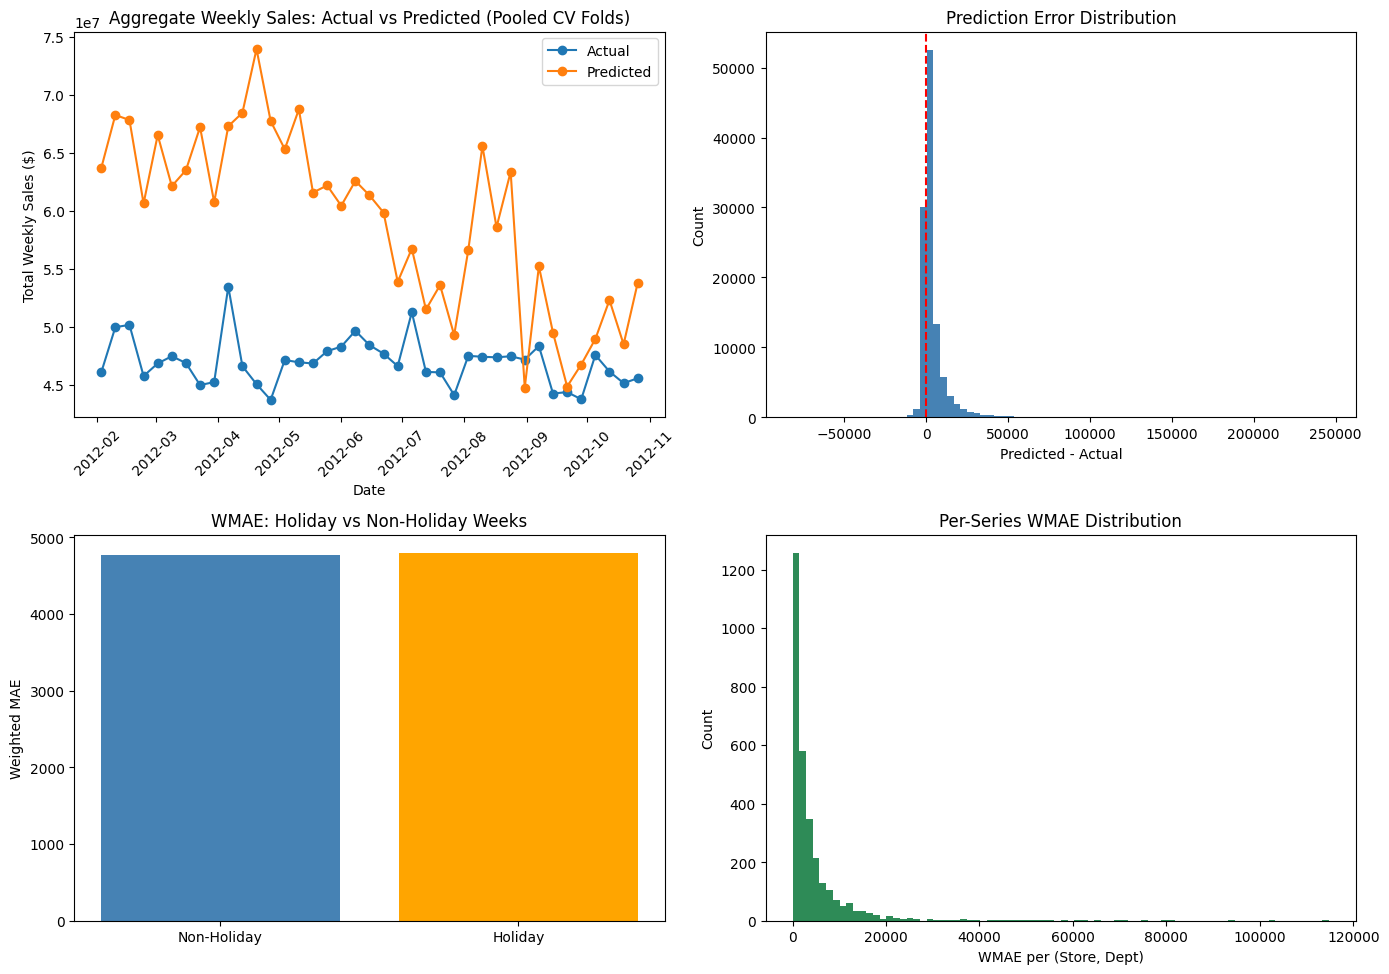

Top 10 worst-performing series (highest WMAE):
Store  Dept
35     72      114821.698149
10     72      102271.540817
14     72       93881.838732
20     72       81321.477265
27     72       81102.055314
14     7        79159.859202
39     72       75527.788765
10     7        71210.749530
22     72       68958.049751
23     72       64867.869211
dtype: float64


In [13]:
scored["error"] = scored["Weekly_Sales_Pred"] - scored["Weekly_Sales"]
scored["abs_error"] = scored["error"].abs()
scored["weight"] = scored["IsHoliday"].map({True: 5, False: 1})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

agg = scored.groupby("Date")[["Weekly_Sales", "Weekly_Sales_Pred"]].sum().sort_index()
axes[0, 0].plot(agg.index, agg["Weekly_Sales"], label="Actual", marker="o")
axes[0, 0].plot(agg.index, agg["Weekly_Sales_Pred"], label="Predicted", marker="o")
axes[0, 0].set_title("Aggregate Weekly Sales: Actual vs Predicted (Pooled CV Folds)")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Total Weekly Sales ($)")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].hist(scored["error"], bins=80, color="steelblue")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_title("Prediction Error Distribution")
axes[0, 1].set_xlabel("Predicted - Actual")
axes[0, 1].set_ylabel("Count")

by_holiday = scored.groupby("IsHoliday")[["abs_error", "weight"]].apply(
    lambda g: (g["abs_error"] * g["weight"]).sum() / g["weight"].sum()
)
axes[1, 0].bar(["Non-Holiday", "Holiday"], by_holiday.values, color=["steelblue", "orange"])
axes[1, 0].set_title("WMAE: Holiday vs Non-Holiday Weeks")
axes[1, 0].set_ylabel("Weighted MAE")

def series_wmae(g):
    w = g["IsHoliday"].map({True: 5, False: 1})
    return (g["abs_error"] * w).sum() / w.sum()

per_series = scored.groupby(["Store", "Dept"])[["IsHoliday", "abs_error"]].apply(series_wmae).sort_values(ascending=False)
axes[1, 1].hist(per_series, bins=80, color="seagreen")
axes[1, 1].set_title("Per-Series WMAE Distribution")
axes[1, 1].set_xlabel("WMAE per (Store, Dept)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../submissions/dlinear_diagnostics.png", dpi=120)
plt.show()

print("Top 10 worst-performing series (highest WMAE):")
print(per_series.head(10))

##  Required `.predict()` wrapper (`DartsForecastPipeline`)

Per `CLAUDE.md`, every model needs a pipeline-shaped wrapper that takes raw,
unpreprocessed `test.csv`-shaped data and handles everything internally, so
`model_inference.ipynb` can call it directly. Scales each series with its own
fitted `Scaler`, keyed by `(Store, Dept)` identity rather than list position -
darts' `Scaler` otherwise matches fitted params to series by position, which
breaks as soon as any series gets filtered out (exactly what caused the
`Only N TimeSeries were provided...` mismatch warning in this notebook's
earlier version).

**Open design question, flagged rather than silently resolved:** the darts
model needs `input_chunk_length` weeks of recent history immediately before
each forecast to condition on. `test.csv` alone doesn't contain that history
(it starts right where train ends) - so `predict()` below pulls train history
via the preprocessor rather than relying solely on whatever `raw_test_df`
contains. Confirm this matches how `model_inference.ipynb` will actually call
it once that notebook exists (joint work with Person A).

In [14]:
class DartsForecastPipeline:
    def __init__(self, darts_model, preprocessor, scaler_target_by_key, df_scaler,
                 numeric_cols, future_covariate_cols, past_covariate_cols,
                 all_covariate_cols, train_history_df, freq="W-FRI",
                 output_chunk_length=39, min_required_length=91):
        self.darts_model = darts_model
        self.preprocessor = preprocessor
        self.scaler_target_by_key = scaler_target_by_key
        self.df_scaler = df_scaler
        self.numeric_cols = numeric_cols
        self.future_covariate_cols = future_covariate_cols
        self.past_covariate_cols = past_covariate_cols
        self.all_covariate_cols = all_covariate_cols
        self.train_history_df = train_history_df
        self.freq = freq
        self.output_chunk_length = output_chunk_length
        self.min_required_length = min_required_length

    def predict(self, raw_test_df):
        test_clean = self.preprocessor.transform(raw_test_df)
        test_feat_local = add_temporal_features(test_clean)

        combined = pd.concat(
            [self.train_history_df, test_feat_local], ignore_index=True, sort=False
        ).drop_duplicates(subset=["Store", "Dept", "Date"])
        combined[self.numeric_cols] = self.df_scaler.transform(combined[self.numeric_cols])

        target_hist, _, keys = build_darts_series(
            self.train_history_df, value_col="Weekly_Sales", covariate_cols=[], freq=self.freq
        )
        # Scale each series with its own fitted scaler, keyed by (Store, Dept) identity
        # rather than list position - darts' Scaler otherwise matches fitted params to
        # series by position, which breaks as soon as any series gets filtered out below.
        target_hist_scaled = [
            self.scaler_target_by_key[key].transform(ts) for ts, key in zip(target_hist, keys)
        ]

        global_start = combined["Date"].min()
        global_end = combined["Date"].max()
        store_cov = build_store_level_covariates(
            combined, self.all_covariate_cols, global_start, global_end, freq=self.freq
        )

        filtered_target, filtered_cov, filtered_keys = [], [], []
        for tgt, key in zip(target_hist_scaled, keys):
            if len(tgt) >= self.min_required_length:
                filtered_target.append(tgt)
                filtered_cov.append(store_cov[key[0]])
                filtered_keys.append(key)

        past_cov = [ts[self.past_covariate_cols] for ts in filtered_cov] if self.past_covariate_cols else None
        future_cov = [ts[self.future_covariate_cols] for ts in filtered_cov] if self.future_covariate_cols else None

        preds_scaled = self.darts_model.predict(
            n=self.output_chunk_length,
            series=filtered_target,
            past_covariates=past_cov if self.darts_model.supports_past_covariates else None,
            future_covariates=future_cov if self.darts_model.supports_future_covariates else None,
        )
        # Inverse-transform each prediction with the scaler fitted for that exact
        # (Store, Dept) series - again by key, not by position in preds_scaled.
        preds = [
            self.scaler_target_by_key[key].inverse_transform(ts)
            for ts, key in zip(preds_scaled, filtered_keys)
        ]

        rows = []
        for (store, dept), ts in zip(filtered_keys, preds):
            df = ts.to_dataframe().reset_index()
            df.columns = ["Date", "Weekly_Sales"]
            df["Store"] = store
            df["Dept"] = dept
            rows.append(df)
        result = pd.concat(rows, ignore_index=True)

        result["Id"] = (
            result["Store"].astype(str) + "_" +
            result["Dept"].astype(str) + "_" +
            result["Date"].dt.strftime("%Y-%m-%d")
        )
        return result[["Id", "Weekly_Sales"]]

##  Final fit on full history and log `DLinear_Final`

Refits on all available train data with a fresh model instance (never reuse
a model object whose `.fit()` already ran, in case an earlier build left it
poisoned), wraps it, and logs the wrapper (not the bare darts model) as the
run artifact so `model_inference.ipynb` can load it directly. Pickling +
`log_artifact` here for simplicity - swap for `mlflow.pyfunc.log_model` with
a custom `PythonModel` if you'd rather have MLflow manage the loading
interface.

In [15]:
scaler_target_by_key = {}
target_full_scaled = []
for tgt, key in zip(target_series, series_keys):
    sc = Scaler()
    target_full_scaled.append(sc.fit_transform(tgt))
    scaler_target_by_key[key] = sc

final_target, final_cov, final_keys = [], [], []
for tgt, key in zip(target_full_scaled, series_keys):
    if len(tgt) >= MIN_REQUIRED_LENGTH:
        final_target.append(tgt)
        final_cov.append(store_cov_series[key[0]])
        final_keys.append(key)

print(f"Original series: {len(target_full_scaled)}")
print(f"Filtered series for final fit: {len(final_target)}")
print(f"Dropped (too short for input+output chunk length): {len(target_full_scaled) - len(final_target)}")

past_full, future_full = split_past_future(final_cov, DLINEAR_FUTURE_COLS, DLINEAR_PAST_COLS)

n_nan_targets = sum(int(np.isnan(ts.values()).sum()) for ts in final_target)
n_nan_covs = sum(int(np.isnan(ts.values()).sum()) for ts in final_cov)
print(f"NaN count in target inputs: {n_nan_targets}")
print(f"NaN count in covariate inputs: {n_nan_covs}")
assert n_nan_targets == 0 and n_nan_covs == 0, "NaNs present in final fit inputs - stop"

# Same DLINEAR_ARCH_KWARGS as every CV fold - no early stopping here since the final
# fit uses all available history with no held-out val set to monitor val_loss against.
final_model = DLinearModel(
    n_epochs=FINAL_N_EPOCHS,
    batch_size=256,
    pl_trainer_kwargs=make_accelerator_kwargs(),
    **DLINEAR_ARCH_KWARGS,
)
final_model.fit(
    series=final_target,
    past_covariates=past_full if SUPPORTS_PAST else None,
    future_covariates=future_full if SUPPORTS_FUTURE else None,
)

pipeline = DartsForecastPipeline(
    darts_model=final_model,
    preprocessor=preprocessor,
    scaler_target_by_key=scaler_target_by_key,
    df_scaler=df_scaler,
    numeric_cols=numeric_cols,
    future_covariate_cols=DLINEAR_FUTURE_COLS,
    past_covariate_cols=DLINEAR_PAST_COLS,
    all_covariate_cols=all_covariate_cols,
    train_history_df=train_feat,
    freq=FREQ,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    min_required_length=MIN_REQUIRED_LENGTH,
)

with mlflow.start_run(run_name="DLinear_Final") as final_run:
    mlflow.log_params({
        "n_epochs": FINAL_N_EPOCHS,
        "future_covariates": ",".join(DLINEAR_FUTURE_COLS) if DLINEAR_FUTURE_COLS else "none (unsupported)",
        "past_covariates": ",".join(DLINEAR_PAST_COLS),
        "n_series_final": len(final_target),
        "cv_strategy": "expanding_window",
        "n_splits": N_SPLITS,
        "val_weeks": VAL_WEEKS,
        **DLINEAR_ARCH_KWARGS,
    })
    mlflow.log_metric("cv_wmae_mean_at_selection", wmae_mean)
    mlflow.log_metric("cv_wmae_std_at_selection", wmae_std)
    mlflow.log_metric("cv_mae_mean_at_selection", mae_mean)

    with tempfile.TemporaryDirectory() as tmp:
        pkl_path = f"{tmp}/dlinear_pipeline.pkl"
        with open(pkl_path, "wb") as f:
            pickle.dump(pipeline, f)
        mlflow.log_artifact(pkl_path, artifact_path="pipeline")

    final_run_id = final_run.info.run_id

print("Logged DLinear_Final wrapper artifact, run_id:", final_run_id)

Original series: 3331
Filtered series for final fit: 3123
Dropped (too short for input+output chunk length): 208


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 36.5 K | train
7 | linear_trend    | Linear           | 36.5 K | train
8 | linear_fut_cov  | Linear           | 17     | train
-------------------------------------------------------------
73.1 K    Trainable params
0

NaN count in target inputs: 0
NaN count in covariate inputs: 0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


🏃 View run DLinear_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4/runs/4daea536de2649e6ab55bdf0e7089c20
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4
Logged DLinear_Final wrapper artifact, run_id: 4daea536de2649e6ab55bdf0e7089c20


##  Generate submission CSV

Reconciles against `sampleSubmission.csv` exactly - drops any predicted rows
beyond what's required, fills any missing ones (dropped short-history
series) with a store/dept mean fallback, so the row count and ID set match
precisely, not just approximately. Also pushes the submission CSV and the
diagnostics PNG to MLflow as artifacts on `DLinear_Final`, so the final run
carries everything needed to reproduce/inspect the result, not just the
pipeline pickle.

In [16]:
submission = pipeline.predict(test_raw)

sample = pd.read_csv("../data/raw/sampleSubmission.csv")
required_ids = set(sample["Id"])

extra_ids = set(submission["Id"]) - required_ids
print("Extra rows generated beyond what's needed:", len(extra_ids))

submission_filtered = submission[submission["Id"].isin(required_ids)].copy()
missing_ids = required_ids - set(submission_filtered["Id"])
print("Still missing after filtering:", len(missing_ids))

fallback_lookup = train_feat.groupby(["Store", "Dept"])["Weekly_Sales"].mean().to_dict()
global_fallback = train_feat["Weekly_Sales"].mean()

missing_df = pd.DataFrame({"Id": sorted(missing_ids)})
parts = missing_df["Id"].str.rsplit("_", n=1, expand=True)
store_dept = parts[0].str.split("_", n=1, expand=True)
missing_df["Store"] = store_dept[0].astype(int)
missing_df["Dept"] = store_dept[1].astype(int)
missing_df["Weekly_Sales"] = missing_df.apply(
    lambda r: fallback_lookup.get((r["Store"], r["Dept"]), global_fallback), axis=1
)

final_submission = pd.concat(
    [submission_filtered, missing_df[["Id", "Weekly_Sales"]]], ignore_index=True
).sort_values("Id").reset_index(drop=True)

print("Final rows:", len(final_submission), "| Expected:", len(sample))
assert len(final_submission) == len(sample)
assert set(final_submission["Id"]) == required_ids

final_submission.to_csv("../submissions/dlinear_submission.csv", index=False)
final_submission.head()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |          | 0/? [00:00<?, ?it/s]

Extra rows generated beyond what's needed: 8176
Still missing after filtering: 1443
Final rows: 115064 | Expected: 115064


,Id,Weekly_Sales
0,10_10_2012-11-02,42409.025033
1,10_10_2012-11-09,50824.058310
2,10_10_2012-11-16,45280.781914
3,10_10_2012-11-23,49041.526740
4,10_10_2012-11-30,41285.395766


In [17]:
with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("../submissions/dlinear_submission.csv")
    mlflow.log_artifact("../submissions/dlinear_diagnostics.png")

print("Submission + diagnostics logged as artifacts on DLinear_Final (run_id:", final_run_id, ")")

🏃 View run DLinear_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4/runs/4daea536de2649e6ab55bdf0e7089c20
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/4
Submission + diagnostics logged as artifacts on DLinear_Final (run_id: 4daea536de2649e6ab55bdf0e7089c20 )
